# 5-17 regression confidence -> DCASE baseline

This notebook loads `outputs/confidence_regression_outputs/C_audio_text_class_dropout_0.5_model.pt`, predicts continuous confidence scores only for `train_pool`, and trains downstream baseline models on predicted confidence `>= 2`, `>= 3`, and `>= 4`.

The fixed `final_test 20%` is never scored or filtered.

In [1]:
from pathlib import Path
import sys

HERE = Path.cwd()
if not (HERE / 'confidence_baseline_common.py').exists():
    sys.path.insert(0, str(HERE / 'baseline_confidnce_train'))
else:
    sys.path.insert(0, str(HERE))

from confidence_baseline_common import (
    ROOT,
    load_baseline_assets,
    make_fixed_holdout,
    load_517_regression_scores,
    run_downstream_grid,
    confidence_threshold_specs,
)

SEED = 1821
BASELINE_MODES = ('both',)
USE_KFOLD = True
N_FOLDS = 5
NUM_EPOCHS = 100
BATCH_SIZE = 64

full_df, _, _ = load_baseline_assets(ROOT)
tmp_out = ROOT / 'baseline_confidnce_train' / 'outputs' / '517_regression'
train_pool, final_test, _ = make_fixed_holdout(full_df, tmp_out, seed=SEED)
score_df = load_517_regression_scores(train_pool, ROOT)
score_df.head()

[517 regression] loading features 1/8,764 | kept=0 | skipped=0
[517 regression] loading features 1,000/8,764 | kept=999 | skipped=0
[517 regression] loading features 2,000/8,764 | kept=1,999 | skipped=0
[517 regression] loading features 3,000/8,764 | kept=2,999 | skipped=0
[517 regression] loading features 4,000/8,764 | kept=3,999 | skipped=0
[517 regression] loading features 5,000/8,764 | kept=4,999 | skipped=0
[517 regression] loading features 6,000/8,764 | kept=5,999 | skipped=0
[517 regression] loading features 7,000/8,764 | kept=6,999 | skipped=0
[517 regression] loading features 8,000/8,764 | kept=7,999 | skipped=0
[517 regression] loading features 8,764/8,764 | kept=8,763 | skipped=0
[517 regression] inference device: cuda
[517 regression] saved scores: c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\train_pool_regression_scores.csv


,sound_id,predicted_confidence_score
0,185755,3.177689
1,432206,3.380891
2,80630,3.806050
3,145544,3.759196
4,156796,3.501560


In [2]:
summary, filter_counts = run_downstream_grid(
    experiment_name='517_regression_continuous_score',
    score_df=score_df,
    output_root=ROOT / 'baseline_confidnce_train' / 'outputs' / '517_regression',
    score_col='predicted_confidence_score',
    threshold_specs=confidence_threshold_specs([2, 3, 4]),
    baseline_modes=BASELINE_MODES,
    use_kfold=USE_KFOLD,
    n_folds=N_FOLDS,
    seed=SEED,
    missing_score_policy='drop',
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
)
display(filter_counts)
summary


=== Filter counts ===
filter_label               score_column  threshold  display_threshold  train_pool_samples  retained_samples  dropped_samples  retained_ratio  num_classes_retained
   pred_ge_2 predicted_confidence_score        2.0                  2                8764              8763                1        0.999886                    23
   pred_ge_3 predicted_confidence_score        3.0                  3                8764              8155              609        0.930511                    23
   pred_ge_4 predicted_confidence_score        4.0                  4                8764              1289             7475        0.147079                    19

=== Downstream baseline plan ===
experiment=517_regression_continuous_score
device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
baseline_modes=('both',)
use_kfold=True, n_folds=5
thresholds=[2, 3, 4]
planned_trainings=15
num_epochs=100, batch_size=64

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.29%
[BaseClassifier | Fold final_test] Top class accuracy: 89.37%
[BaseClassifier | Fold final_test] Macro accuracy: 73.83%
[BaseClassifier | Fold final_test] Macro top class accuracy: 84.82%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.32%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.29%
[BaseClassifier | Fold final_test] Hierarchical recall: 77.95%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.40%
  completed in 8.6 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_2\both\fold_1
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=7010, val=1753, final_test=2192
  batches: train=109, val=28, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 56.02%
  New best model saved
Epoch [2/100] - Val acc: 67.83%
  New best model saved
Epoch [3/100] - Val acc: 72.05%
  New best model saved
Epoch [4/100] - Val acc: 75.30%
  N

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 80.25%
[BaseClassifier | Fold final_test] Top class accuracy: 89.01%
[BaseClassifier | Fold final_test] Macro accuracy: 74.70%
[BaseClassifier | Fold final_test] Macro top class accuracy: 84.94%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 79.82%
[BaseClassifier | Fold final_test] Hierarchical precision: 79.65%
[BaseClassifier | Fold final_test] Hierarchical recall: 78.54%
[BaseClassifier | Fold final_test] Hierarchical F1: 78.86%
  completed in 9.0 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_2\both\fold_2
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=7010, val=1753, final_test=2192
  batches: train=109, val=28, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 58.64%
  New best model saved
Epoch [2/100] - Val acc: 66.91%
  New best model saved
Epoch [3/100] - Val acc: 73.47%
  New best model saved
Epoch [4/100] - Val acc: 74.90%
  N

...

[BaseClassifier | Fold final_test] Accuracy: 56.89%
[BaseClassifier | Fold final_test] Top class accuracy: 74.86%
[BaseClassifier | Fold final_test] Macro accuracy: 43.46%
[BaseClassifier | Fold final_test] Macro top class accuracy: 67.09%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 55.27%
[BaseClassifier | Fold final_test] Hierarchical precision: 62.46%
[BaseClassifier | Fold final_test] Hierarchical recall: 72.70%
[BaseClassifier | Fold final_test] Hierarchical F1: 66.08%
  completed in 0.6 min

[run] c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_4\both\fold_4
  device=cuda:0 (NVIDIA GeForce RTX 3060, 8.6 GB)
  samples: train=1032, val=257, final_test=2192
  batches: train=16, val=5, test=35
  max_epochs=100, batch_size=64
Epoch [1/100] - Val acc: 10.12%
  New best model saved
Epoch [2/100] - Val acc: 44.36%
  New best model saved
Epoch [3/100] - Val acc: 74.71%
  New best model saved
Epoch [4/100] - Val acc: 82.88%
  New 

c:\Users\solok\Desktop\Dcase baseline\dcase2026_task1_baseline\evaluate.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location

[BaseClassifier | Fold final_test] Accuracy: 57.25%
[BaseClassifier | Fold final_test] Top class accuracy: 73.86%
[BaseClassifier | Fold final_test] Macro accuracy: 43.43%
[BaseClassifier | Fold final_test] Macro top class accuracy: 65.22%
[BaseClassifier | Fold final_test] Hierarchical accuracy: 54.32%
[BaseClassifier | Fold final_test] Hierarchical precision: 58.69%
[BaseClassifier | Fold final_test] Hierarchical recall: 66.64%
[BaseClassifier | Fold final_test] Hierarchical F1: 61.44%
  completed in 0.7 min


,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,dropped_samples,retained_ratio,num_classes_retained
0,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,1,0.999886,23
1,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,609,0.930511,23
2,pred_ge_4,predicted_confidence_score,4.0,4,8764,1289,7475,0.147079,19


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
0,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,80.604678,80.291971,89.370438,73.833666,84.816286,79.324976,79.285289,77.952149,78.395820,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,80.262407,80.246350,89.005474,74.696170,84.940443,79.818307,79.647991,78.537773,78.855344,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,79.806047,80.839416,89.142336,75.353190,84.876379,80.114784,79.959237,78.924385,79.311229,c:\Users\solok\Desktop\Dcase baseline\baseline...
3,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,79.965753,81.250000,89.507299,75.711294,85.592309,80.651801,80.820224,79.416675,79.778602,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,79.623288,79.197080,88.093066,71.304289,82.321700,76.812994,79.435472,75.435818,76.334154,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,80.748007,80.291971,89.826642,74.215347,85.371702,79.793524,79.248270,78.398980,78.659954,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,80.380135,80.702555,89.233577,74.849110,85.145698,79.997404,79.230426,78.710330,78.579734,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,81.606376,79.972628,89.233577,74.622485,85.159572,79.891029,79.902144,78.573893,78.943931,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,81.667689,80.018248,89.370438,73.092354,84.723344,78.907849,79.797008,77.453975,77.999206,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,81.790313,79.790146,89.461679,73.263426,84.876720,79.070073,79.002568,77.618411,77.963078,c:\Users\solok\Desktop\Dcase baseline\baseline...



=== All downstream run results ===
source: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\summary_results.csv
saved view: C:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\all_run_results_view.csv
filter_label  threshold  retained_samples  retained_ratio mode  split  train_samples  val_samples  final_test_samples  best_val_accuracy  accuracy  top_accuracy  macro_accuracy  hierarchical_accuracy  hierarchical_precision  hierarchical_recall  hierarchical_f1                                                                                                  output_dir
   pred_ge_2        2.0              8763        0.999886 both fold_3           7011         1752                2192          79.965753 81.250000     89.507299       75.711294              80.651801               80.820224            79.416675        79.778602 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_2

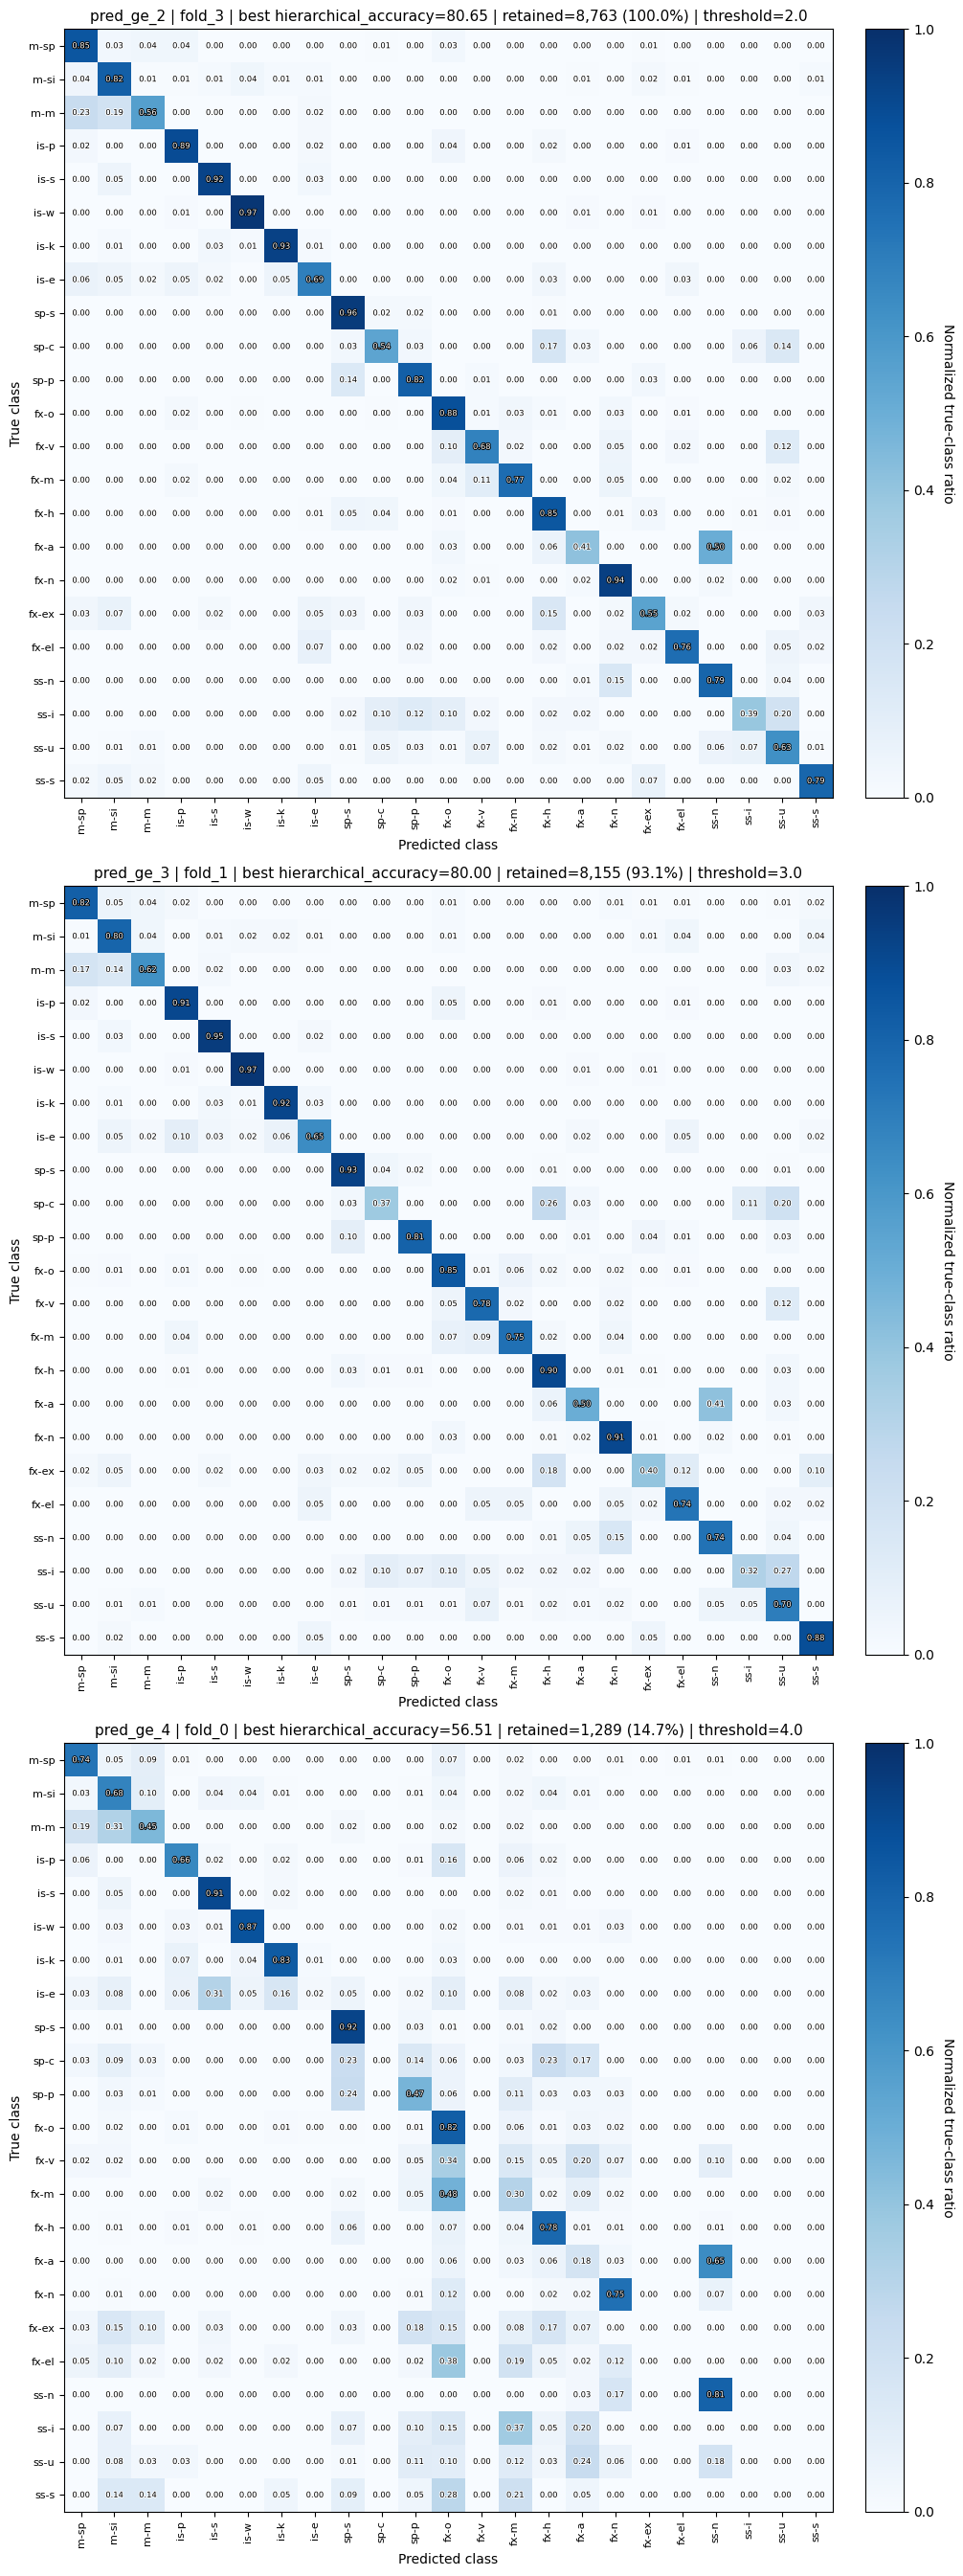


=== Best folds selected for confusion matrix ===
filter_label  threshold mode  split  retained_samples  retained_ratio  best_val_accuracy  accuracy  hierarchical_f1                                                                                                  output_dir
   pred_ge_2        2.0 both fold_3              8763        0.999886          79.965753 81.250000        79.778602 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_2\both\fold_3
   pred_ge_3        3.0 both fold_1              8155        0.930511          80.380135 80.702555        78.579734 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_3\both\fold_1
   pred_ge_4        4.0 both fold_0              1289        0.147079          91.860465 58.394161        61.884381 c:\Users\solok\Desktop\Dcase baseline\baseline_confidnce_train\outputs\517_regression\pred_ge_4\both\fold_0

saved best-fold table: C:\Users\solok\Desktop\Dcase b

,filter_label,threshold,retained_samples,retained_ratio,mode,split,train_samples,val_samples,final_test_samples,best_val_accuracy,accuracy,top_accuracy,macro_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir
3,pred_ge_2,2.0,8763,0.999886,both,fold_3,7011,1752,2192,79.965753,81.250000,89.507299,75.711294,80.651801,80.820224,79.416675,79.778602,c:\Users\solok\Desktop\Dcase baseline\baseline...
2,pred_ge_2,2.0,8763,0.999886,both,fold_2,7010,1753,2192,79.806047,80.839416,89.142336,75.353190,80.114784,79.959237,78.924385,79.311229,c:\Users\solok\Desktop\Dcase baseline\baseline...
6,pred_ge_3,3.0,8155,0.930511,both,fold_1,6524,1631,2192,80.380135,80.702555,89.233577,74.849110,79.997404,79.230426,78.710330,78.579734,c:\Users\solok\Desktop\Dcase baseline\baseline...
7,pred_ge_3,3.0,8155,0.930511,both,fold_2,6524,1631,2192,81.606376,79.972628,89.233577,74.622485,79.891029,79.902144,78.573893,78.943931,c:\Users\solok\Desktop\Dcase baseline\baseline...
1,pred_ge_2,2.0,8763,0.999886,both,fold_1,7010,1753,2192,80.262407,80.246350,89.005474,74.696170,79.818307,79.647991,78.537773,78.855344,c:\Users\solok\Desktop\Dcase baseline\baseline...
5,pred_ge_3,3.0,8155,0.930511,both,fold_0,6524,1631,2192,80.748007,80.291971,89.826642,74.215347,79.793524,79.248270,78.398980,78.659954,c:\Users\solok\Desktop\Dcase baseline\baseline...
0,pred_ge_2,2.0,8763,0.999886,both,fold_0,7010,1753,2192,80.604678,80.291971,89.370438,73.833666,79.324976,79.285289,77.952149,78.395820,c:\Users\solok\Desktop\Dcase baseline\baseline...
9,pred_ge_3,3.0,8155,0.930511,both,fold_4,6524,1631,2192,81.790313,79.790146,89.461679,73.263426,79.070073,79.002568,77.618411,77.963078,c:\Users\solok\Desktop\Dcase baseline\baseline...
8,pred_ge_3,3.0,8155,0.930511,both,fold_3,6524,1631,2192,81.667689,80.018248,89.370438,73.092354,78.907849,79.797008,77.453975,77.999206,c:\Users\solok\Desktop\Dcase baseline\baseline...
4,pred_ge_2,2.0,8763,0.999886,both,fold_4,7011,1752,2192,79.623288,79.197080,88.093066,71.304289,76.812994,79.435472,75.435818,76.334154,c:\Users\solok\Desktop\Dcase baseline\baseline...


,experiment,filter_label,score_column,threshold,display_threshold,train_pool_samples,retained_samples,retained_ratio,final_test_samples,status,...,accuracy,top_accuracy,macro_accuracy,macro_top_accuracy,hierarchical_accuracy,hierarchical_precision,hierarchical_recall,hierarchical_f1,output_dir,fold_num
0,517_regression_continuous_score,pred_ge_2,predicted_confidence_score,2.0,2,8764,8763,0.999886,2192,ok,...,81.250000,89.507299,75.711294,85.592309,80.651801,80.820224,79.416675,79.778602,c:\Users\solok\Desktop\Dcase baseline\baseline...,3.0
1,517_regression_continuous_score,pred_ge_3,predicted_confidence_score,3.0,3,8764,8155,0.930511,2192,ok,...,80.702555,89.233577,74.849110,85.145698,79.997404,79.230426,78.710330,78.579734,c:\Users\solok\Desktop\Dcase baseline\baseline...,1.0
2,517_regression_continuous_score,pred_ge_4,predicted_confidence_score,4.0,4,8764,1289,0.147079,2192,ok,...,58.394161,76.414234,44.296195,68.718568,56.507381,59.269715,68.295633,61.884381,c:\Users\solok\Desktop\Dcase baseline\baseline...,0.0


WindowsPath('C:/Users/solok/Desktop/Dcase baseline/baseline_confidnce_train/outputs/517_regression/best_fold_confusion_matrices_by_hierarchical_accuracy.png')

In [3]:
from pathlib import Path
import sys
import importlib

ROOT = Path(r"C:\Users\solok\Desktop\Dcase baseline")
sys.path.insert(0, str(ROOT))

import baseline_confidnce_train.confidence_baseline_common as cbc
importlib.reload(cbc)

all_results, best_folds, fig_path = cbc.show_v2_5class_results(
    output_root=ROOT / 'baseline_confidnce_train' / 'outputs' / '517_regression'
)
display(all_results)
display(best_folds)
fig_path